# 🚀 **Lab 05 — NLP & Attention Mechanisms: A Discovery Journey with words**

### **Instructor: Dr. Andrea Ramirez-Salgado**

## Welcome, Deep Learning Explorer!

Ever wonder how a machine *reads* a movie review and knows whether it's glowing praise or scathing criticism? In this lab, you'll build exactly that — an **attention-based sentiment analyzer** trained on 50,000 IMDb movie reviews. More than just classifying text, you'll **see** what your model is paying attention to with beautiful visualizations.

---

### 🎯 **What You'll Discover**
- How raw text becomes numbers a neural network can reason about (tokenization & vocabularies)
- Why word embeddings are like maps for meaning — and how to build them
- How **scaled dot-product attention** lets a model selectively focus on the most important words
- How to visualize and interpret what your model is actually "reading"
- The real trade-offs between accuracy, efficiency, and interpretability

### 🧪 **Your Lab Philosophy**
1. **Experiment First**: Try things, make predictions, then see what happens
2. **Visualize Everything**: Attention weights, embeddings, training curves — see it all
3. **Connect Concepts**: Understand the *why* behind every design decision

### 📊 **Your Progress Tracker**
Throughout this lab, you'll complete:
- 🔵 **Discovery Tasks** — Explore and build intuition
- 🟢 **Implementation Tasks** — Build real NLP components
- 🟡 **Reflection Tasks** — Deepen your understanding
- 🔴 **Challenge Tasks** — Push your limits

> **Pro Tip**: The goal isn't to rush through. It's to genuinely understand how modern NLP models work under the hood. Take your time with the reflections!

---
Let's begin! 🎓

---
# 🛠️ **Setup: Your NLP Toolkit**

We'll use Hugging Face's `datasets` library (instead of the deprecated `torchtext`) to load IMDb reviews cleanly.

```bash
# Recommended: create a dedicated environment
conda create -n deep-learning python=3.9
conda activate deep-learning
conda install pytorch -c pytorch
pip install datasets matplotlib numpy
```

In [1]:
!pip install datasets --quiet

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import random
import math

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ GPU available: {torch.cuda.is_available()} — using: {device}")
print("\n🎉 You're all set! Let's explore NLP!")

✅ PyTorch version: 2.10.0+cu128
✅ GPU available: True — using: cuda

🎉 You're all set! Let's explore NLP!


---
# **Part 1: From Text to Numbers** 📝

## **Why This Matters**

Neural networks can only work with numbers — not words. The entire first step of any NLP pipeline is converting raw text into a numerical representation that preserves meaning. This is harder than it sounds: "not bad" and "terrible" are about as far apart as you can get in meaning, but naively they share no words.

We'll go through three key steps:
1. **Tokenization** — Splitting text into units (tokens)
2. **Vocabulary building** — Creating a word→integer dictionary
3. **Encoding** — Converting sentences to fixed-length integer sequences

Think of this like creating a dictionary: each word gets a unique ID number, and sentences become sequences of those ID numbers.

## **1.1 Load the IMDb Dataset**

### 🔵 **Discovery Task 1: Explore the Data**

**Your Mission**: Before building any model, understand your data! Run the cell below and examine a few reviews. Ask yourself: What patterns do you notice? What makes a review obviously positive or negative?

In [3]:
dataset = load_dataset("imdb")

# ⚡ Speed setting: use a smaller subset so training is feasible on CPU
# Change TRAIN_SIZE/TEST_SIZE to None to use full 25k/25k dataset (GPU recommended)
TRAIN_SIZE = 5000
TEST_SIZE  = 2000

import random
random.seed(42)
train_indices = random.sample(range(len(dataset["train"])), TRAIN_SIZE)
test_indices  = random.sample(range(len(dataset["test"])),  TEST_SIZE)
train_data = dataset["train"].select(train_indices)
test_data  = dataset["test"].select(test_indices)

print(f"📚 Training samples: {len(train_data):,}")
print(f"📚 Test samples:     {len(test_data):,}")
print("💡 Tip: On GPU/HiPerGator set TRAIN_SIZE=None for full dataset and higher accuracy.")

# Show 3 random samples
print("\n" + "="*60)
for i, ex in enumerate(random.sample(list(train_data), 3), start=1):
    sentiment = "⭐ POSITIVE" if ex["label"] == 1 else "💀 NEGATIVE"
    print(f"\nExample {i} [{sentiment}]")
    print("-"*40)
    print(ex["text"][:400] + "...")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

📚 Training samples: 5,000
📚 Test samples:     2,000
💡 Tip: On GPU/HiPerGator set TRAIN_SIZE=None for full dataset and higher accuracy.


Example 1 [💀 NEGATIVE]
----------------------------------------
If this is someone's "favorite" movie, they need some serious help. There is nothing funny or clever about this crapfest. I haven't seen the original movie this is the remake of (some 1950s film), but it simply has to be better than this newer bastardization.<br /><br />A major gets kicked out of the military for being a fringe element, and winds up teaching children at an ROTC school. Unfortunate...

Example 2 [⭐ POSITIVE]
----------------------------------------
Well here comes another,well,romantic comedy...but unlike all others movies of this genre,this is by far the best I have seen in a long while..<br /><br />I'll admit,at first I wanted to watch this movie because of Megan Fox,and a little because of Simon Pegg...<br /><br />First of all,if you have watched a decent amount of movi

### 🟡 **Reflection 1: Data Intuition**

Before tokenizing anything, take a moment to think:

1. What words or phrases do you think will be the strongest predictors of positive/negative sentiment?
2. What challenges might a simple word-splitting approach have with movie reviews? (Think about punctuation, slang, phrases like "not bad"...)
3. What information is *lost* when we convert text to a bag of words vs. preserving word order?

*Your answers (double-click to edit):*

1. Strong predictors of negative sentiment are emotionally charged words and phrases such as “crapfest,” “nothing funny,” “utterly tasteless,” “fake-looking,” “worst,” “awful,” and “waste of time.”

Strong predictors of positive sentiment include phrases like “by far the best,” “great,” “amazing,” “excellent,” “loved,” and “well done.”

Intensifiers like “very,” “extremely,” and “by far” can also strengthen sentiment.

2.Negation problems: Phrases like “not bad” are positive, but splitting into “not” and “bad” may incorrectly suggest negative sentiment.

Sarcasm: A sentence like “Yeah, that was just brilliant...” may actually be negative, but simple models cannot detect sarcasm.
Punctuation issues: Words like “best!!!” and “best” become different tokens unless cleaned.

3. When converting text to a bag of words, word order is lost. This means sentences like “The movie is not good” and “The movie is good” may look very similar to the model because they contain many of the same words.

Context is also lost. For example, in the sentence “I thought it would be great, but it wasn’t,” the word “great” appears, but the overall sentiment is negative.

Additionally, relationships between words and overall sentence structure are ignored, which reduces the model’s ability to fully understand meaning.

## **1.2 Tokenization and Vocabulary**

### 🔵 **Discovery Task 2: Understand Tokenization**

Let's explore what different tokenization approaches produce — before we commit to one.

In [6]:
# Three different tokenization approaches — compare their outputs!
sample_text = "I absolutely LOVED this film! It wasn't perfect, but honestly... 10/10 would recommend."

# Approach 1: Simple whitespace split
tokens_simple = sample_text.lower().split()

# Approach 2: Split + basic punctuation handling
import re
tokens_cleaned = re.sub(r"[^\w\s]", "", sample_text.lower()).split()

# Approach 3: Character n-grams (just for exploration)
tokens_char = [sample_text[i:i+3] for i in range(0, len(sample_text)-2, 2)]

print("Approach 1 - Whitespace:")
print(tokens_simple)
print(f"→ {len(tokens_simple)} tokens\n")

print("Approach 2 - Cleaned:")
print(tokens_cleaned)
print(f"→ {len(tokens_cleaned)} tokens\n")

print("Approach 3 - Character n-grams (first 10):")
print(tokens_char[:10])
print("(This would create a very large vocabulary!")

Approach 1 - Whitespace:
['i', 'absolutely', 'loved', 'this', 'film!', 'it', "wasn't", 'perfect,', 'but', 'honestly...', '10/10', 'would', 'recommend.']
→ 13 tokens

Approach 2 - Cleaned:
['i', 'absolutely', 'loved', 'this', 'film', 'it', 'wasnt', 'perfect', 'but', 'honestly', '1010', 'would', 'recommend']
→ 13 tokens

Approach 3 - Character n-grams (first 10):
['I a', 'abs', 'sol', 'lut', 'tel', 'ly ', ' LO', 'OVE', 'ED ', ' th']
(This would create a very large vocabulary!


### 🔵 **Discovery Task 2b: The Negation Problem — A Required Experiment**

**Before running the cell below**, write your prediction:

> Our tokenizer splits on whitespace. What does `"not good"` become? What about `"wasn't good"`?

*My prediction:*
“not good” becomes:
["not", "good"]

“wasn't good” becomes:
["wasn't", "good"]
(or in the cleaned version: ["wasnt", "good"])

Now run the cell, then answer Reflection 1b below.

In [8]:
# Test our tokenizer on tricky linguistic cases
tricky_sentences = [
    "not good",
    "wasn't good",
    "good, not great",
    "the best worst movie ever",
    "surprisingly not terrible",
]

print("What our tokenizer produces:")
print("=" * 50)
for s in tricky_sentences:
    tokens = s.lower().split()
    print(f"  '{s}'  →  {tokens}")

print("\n💡 Notice: 'wasn't' stays as one token — it's NOT split into 'was' + 'not'.")
print("   If 'wasn't' is rare in training data, the model may not learn its negative meaning.")
print("   A subword tokenizer (BPE, WordPiece) would split it into ['was', '##n', \"'t'\"]).")
print("   That makes negation compositional and better covered by training frequency.")

# After you build the vocab (next cell), come back and check:
# print(f"Frequency of 'not':    {counter.get('not', 0):,}")
# print(f"Frequency of 'wasn't': {counter.get("wasn't", 0):,}")


What our tokenizer produces:
  'not good'  →  ['not', 'good']
  'wasn't good'  →  ["wasn't", 'good']
  'good, not great'  →  ['good,', 'not', 'great']
  'the best worst movie ever'  →  ['the', 'best', 'worst', 'movie', 'ever']
  'surprisingly not terrible'  →  ['surprisingly', 'not', 'terrible']

💡 Notice: 'wasn't' stays as one token — it's NOT split into 'was' + 'not'.
   If 'wasn't' is rare in training data, the model may not learn its negative meaning.
   A subword tokenizer (BPE, WordPiece) would split it into ['was', '##n', "'t'"]).
   That makes negation compositional and better covered by training frequency.


### 🟡 **Reflection 1b: Tokenization and Meaning**

1. **Did the tokenizer behave as you predicted?** What surprised you?

2. **Concretely**: If `"wasn't"` appears only 200 times in training but `"good"` appears 10,000 times, how does that frequency gap hurt the model's ability to detect negation?

3. **Design fix**: What would a better tokenizer do with `"wasn't"`? How would that change the vocab coverage problem?

*Your answers (double-click to edit):*

1. Yes, the tokenizer behaved mostly as expected by splitting only on whitespace. However, it is surprising that “wasn't” stays as a single token instead of being split into “was” and “not.” This means the tokenizer does not explicitly capture negation. It is also noticeable that punctuation remains attached to words, which creates separate tokens and increases vocabulary size unnecessarily.

2.If “wasn't” appears only 200 times but “good” appears 10,000 times, the model will learn a very strong positive association with the word “good.” Because “wasn't” is rare, the model has limited examples to learn that it signals negation. As a result, when the phrase “wasn't good” appears, the strong positive weight of “good” may overpower the weak negative signal from “wasn't.” This frequency imbalance makes it harder for the model to correctly interpret negation and may lead to misclassification.

3.A better tokenizer would split “wasn't” into meaningful subwords such as “was” and “not” (or “n’t”). This allows the model to reuse the already learned meaning of “not” across many different contexts. Subword tokenizers like BPE or WordPiece improve vocabulary coverage by breaking rare words into common components, reducing sparsity and helping the model generalize better to unseen or infrequent words.

### 🟢 **Implementation Task 1: Build the Vocabulary**

**Your Mission**: Complete the vocabulary-building pipeline. This is a critical step — the vocabulary determines what your model can and cannot understand.

Fill in the `None` placeholders. Hints are in the comments!

In [9]:
# Our chosen tokenizer: lowercase + whitespace split
def tokenize(text: str) -> list:
    """Convert text to a list of lowercase tokens.
    NOTE: This naive tokenizer doesn't handle punctuation well —
    that's intentional for now (we'll explore improvements in challenges).
    """
    return text.lower().split()


# Count every word in the training set
counter = Counter()
for example in train_data:
    counter.update(tokenize(example["text"]))

print(f"Total unique words found: {len(counter):,}")
print(f"Top 10 words: {counter.most_common(10)}")

# ============================================================
# 🟢 YOUR TASK: Build the vocabulary dictionary
# ============================================================
MAX_VOCAB = 20000  # Keep only the most frequent words

# Start with special tokens:
# <PAD> = 0 (used to pad short sequences to a fixed length)
# <UNK> = 1 (used for words not in the vocabulary)
vocab = {"<PAD>": 0, "<UNK>": 1}

# TODO: Add the top MAX_VOCAB words to vocab
# Each word should get an integer ID starting from 2
# HINT: Replace the None values by looping over the MAX_VOCAB most common (word, count) pairs,
# and use a running index that starts at 2 so IDs follow <PAD>=0 and <UNK>=1.
for idx, (word, _) in enumerate(counter.most_common(MAX_VOCAB), start=2):  # Fix the None values
    vocab[word] = idx

vocab_size = len(vocab)
print(f"\n✅ Vocabulary size: {vocab_size:,}")
print(f"   (Including 2 special tokens: <PAD>=0, <UNK>=1)")
print(f"\n🔍 Example lookups:")
print(f"   'movie' → ID {vocab.get('movie', 1)}")
print(f"   'terrible' → ID {vocab.get('terrible', 1)}")
print(f"   'zzz_not_in_vocab' → ID {vocab.get('zzz_not_in_vocab', 1)} (<UNK>)")

Total unique words found: 91,997
Top 10 words: [('the', 63947), ('a', 31884), ('and', 31561), ('of', 28574), ('to', 26562), ('is', 20857), ('in', 17985), ('i', 14208), ('this', 13932), ('that', 13314)]

✅ Vocabulary size: 20,002
   (Including 2 special tokens: <PAD>=0, <UNK>=1)

🔍 Example lookups:
   'movie' → ID 20
   'terrible' → ID 509
   'zzz_not_in_vocab' → ID 1 (<UNK>)


### 🟢 **Implementation Task 2: Sentence Encoder**

**Your Mission**: Implement the `encode_sentence` function that converts a text string into a fixed-length tensor of token IDs.

In [10]:
def encode_sentence(sentence: str, max_len: int = 100) -> torch.Tensor:
    """
    Convert a text sentence into a fixed-length tensor of vocabulary IDs.

    Steps:
    1. Tokenize the sentence
    2. Map each token to its vocab ID (use <UNK>=1 for unknown words)
    3. Truncate to max_len if too long
    4. Pad with <PAD>=0 if too short
    5. Return as a torch.long tensor

    Args:
        sentence: raw input string
        max_len: target sequence length
    Returns:
        tensor of shape (max_len,) with token IDs
    """
    tokens = tokenize(sentence)

    # TODO: Map each token to its vocab ID
    # Hint: vocab.get(tok, vocab["<UNK>"]) handles unknown words
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]  # Your code here

    # TODO: Truncate to max_len
    ids = ids[:max_len] # Your code here (slice the list)

    # TODO: Pad to max_len with <PAD> token (ID=0)
    pad_len = max_len - len(ids)
    if pad_len > 0:
        ids = ids + [vocab["<PAD>"]] * pad_len  # Your code here

    return torch.tensor(ids, dtype=torch.long)


# ---- Verification ----
test_review = "This movie was absolutely fantastic!"
encoded = encode_sentence(test_review, max_len=10)
print(f"Input: '{test_review}'")
print(f"Encoded (max_len=10): {encoded}")
print(f"Shape: {encoded.shape}")
print(f"\nExpected: tensor of shape (10,)")
print(f"Last few tokens should be 0 (padding): {encoded[-3:]}")  # Should be [0, 0, 0]

assert encoded.shape == (10,), "Shape should be (10,)"
assert encoded[-1].item() == 0, "Last token should be <PAD>=0"
print("\n✅ Encoder works correctly!")

Input: 'This movie was absolutely fantastic!'
Encoded (max_len=10): tensor([ 10,  20,  14, 409,   1,   0,   0,   0,   0,   0])
Shape: torch.Size([10])

Expected: tensor of shape (10,)
Last few tokens should be 0 (padding): tensor([0, 0, 0])

✅ Encoder works correctly!


### 📊 **Visualization 1: Word Frequency Distribution**

Understanding your vocabulary's frequency distribution is essential for knowing what your model can and cannot learn.

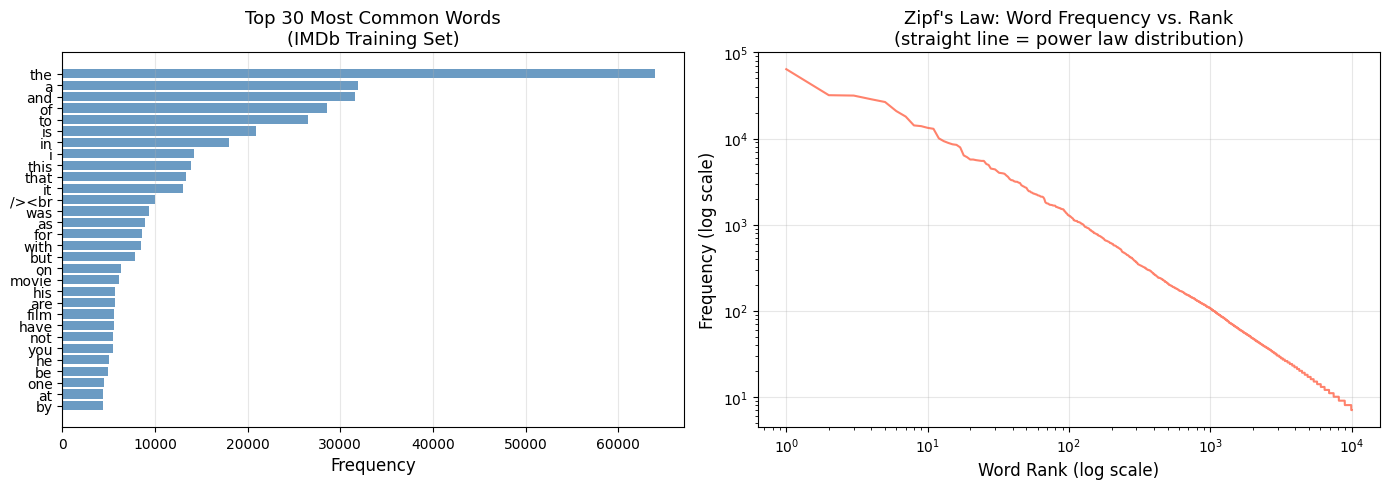


📊 Vocabulary Coverage Analysis:
   Top 20,000 words cover 92.1% of all tokens in the training data
   This means only 7.9% of tokens will map to <UNK>


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Top 30 most common words
top_words = counter.most_common(30)
words, counts = zip(*top_words)
axes[0].barh(words, counts, color='steelblue', alpha=0.8)
axes[0].invert_yaxis()
axes[0].set_xlabel('Frequency', fontsize=12)
axes[0].set_title('Top 30 Most Common Words\n(IMDb Training Set)', fontsize=13)
axes[0].grid(axis='x', alpha=0.3)

# Right plot: Zipf's law — frequency vs. rank (log-log)
all_counts = sorted([c for _, c in counter.most_common(10000)], reverse=True)
axes[1].loglog(range(1, len(all_counts)+1), all_counts, color='tomato', alpha=0.8)
axes[1].set_xlabel('Word Rank (log scale)', fontsize=12)
axes[1].set_ylabel('Frequency (log scale)', fontsize=12)
axes[1].set_title("Zipf's Law: Word Frequency vs. Rank\n(straight line = power law distribution)", fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Coverage analysis
total_tokens = sum(counter.values())
top_vocab_coverage = sum(count for _, count in counter.most_common(MAX_VOCAB))
print(f"\n📊 Vocabulary Coverage Analysis:")
print(f"   Top {MAX_VOCAB:,} words cover {100*top_vocab_coverage/total_tokens:.1f}% of all tokens in the training data")
print(f"   This means only {100*(1 - top_vocab_coverage/total_tokens):.1f}% of tokens will map to <UNK>")

---
# **Part 2: Word Embeddings — Mapping Meaning to Space** 🗺️

## **Why This Matters**

Simple integer IDs (like word→5, movie→12) have a critical flaw: they imply no relationship between words. The number 12 is "closer" to 13 than to 5, but "movie" and "film" are basically synonyms.

**Word embeddings** solve this by mapping each word to a dense vector in a high-dimensional space. Words with similar meanings end up near each other in that space. This is what allows a model to generalize — if it learns that "fantastic" is positive, it can transfer some of that knowledge to "wonderful".

Think of it like a city map: streets have coordinates, and nearby streets are... nearby. Embeddings give words coordinates in meaning-space.

## **2.1 Build the Dataset and DataLoaders**

### 🟢 **Implementation Task 3: Custom Dataset Class**

**Your Mission**: Complete the `IMDBDataset` class. This wraps our data so PyTorch's `DataLoader` can efficiently batch it.

In [12]:
class IMDBDataset(Dataset):
    """PyTorch Dataset wrapper for IMDb reviews."""

    def __init__(self, split: str, max_len: int = 100):
        """
        Args:
            split: 'train' or 'test'
            max_len: maximum sequence length for encoding
        """
        # TODO: Load the correct split from the HuggingFace 'dataset' variable
        self.data = dataset[split]  # The dataset is already organized by split name.
        self.max_len = max_len

    def __len__(self) -> int:
        # TODO: Return the number of samples
        return len(self.data) # Hint: Length should match the size of the stored split.

    def __getitem__(self, idx: int):
        """
        Returns:
            (encoded_text, label) where:
            - encoded_text: torch.LongTensor of shape (max_len,)
            - label: torch.FloatTensor scalar (0.0 or 1.0)
        """
        # TODO: Get the text and label at index idx
        # Hint: Each item is a small dictionary containing the review text and its sentiment label.
        text  = self.data[idx]["text"]
        label = self.data[idx]["label"]

        encoded_text = encode_sentence(text, self.max_len)
        return encoded_text, torch.tensor(label, dtype=torch.float)


def collate_fn(batch):
    """Merge list of (encoded_text, label) samples into a batch."""
    xs, ys = zip(*batch)
    return torch.stack(xs, dim=0), torch.stack(ys, dim=0)


# Create DataLoaders
train_loader = DataLoader(IMDBDataset("train"), batch_size=32, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(IMDBDataset("test"),  batch_size=32, shuffle=False, collate_fn=collate_fn)

# ---- Verification ----
xb, yb = next(iter(train_loader))
print(f"✅ Batch shapes — inputs: {xb.shape}, labels: {yb.shape}")
print(f"   Expected:  inputs: torch.Size([32, 100]), labels: torch.Size([32])")
print(f"   Label values: {torch.unique(yb)} (should be 0.0 and 1.0)")

✅ Batch shapes — inputs: torch.Size([32, 100]), labels: torch.Size([32])
   Expected:  inputs: torch.Size([32, 100]), labels: torch.Size([32])
   Label values: tensor([0., 1.]) (should be 0.0 and 1.0)


### 🔵 **Discovery Task 3: Explore What Embeddings Look Like**

Before training, let's understand what the embedding layer actually produces — and how random embeddings differ from trained ones.

In [13]:
# Create a small embedding layer to explore
embed_dim = 16  # small for visualization
embedding_layer = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

# Look up some words
words_to_check = ["good", "great", "excellent", "terrible", "awful", "movie", "film"]
word_ids = torch.tensor([vocab.get(w, 1) for w in words_to_check])
embeddings = embedding_layer(word_ids).detach()

print("Random (pre-training) embedding for 'good':")
print(embeddings[0].numpy().round(3))

# Compute cosine similarity between words
def cosine_sim(a, b):
    return (a @ b) / (a.norm() * b.norm())

print("\nCosine similarities (before training — should be near-random):")
pairs = [("good", "great"), ("good", "terrible"), ("movie", "film")]
for w1, w2 in pairs:
    e1 = embedding_layer(torch.tensor([vocab.get(w1, 1)])).squeeze()
    e2 = embedding_layer(torch.tensor([vocab.get(w2, 1)])).squeeze()
    sim = cosine_sim(e1.detach(), e2.detach()).item()
    print(f"  '{w1}' vs '{w2}': {sim:.3f}")

print("\n💡 After training, synonyms like 'movie'/'film' should have HIGH similarity,")
print("   while 'good'/'terrible' should have LOW similarity.")

Random (pre-training) embedding for 'good':
[-0.2    0.995  0.72  -0.134 -0.164  1.339  2.005 -1.581 -0.157  1.138
 -0.251  1.67   1.889 -0.754 -1.714 -2.207]

Cosine similarities (before training — should be near-random):
  'good' vs 'great': -0.293
  'good' vs 'terrible': 0.054
  'movie' vs 'film': 0.347

💡 After training, synonyms like 'movie'/'film' should have HIGH similarity,
   while 'good'/'terrible' should have LOW similarity.


---
# **Part 3: The Attention Mechanism** 👁️

## **Why This Matters**

Here's the core problem with simple averaging: if you pool all word embeddings equally, "not good" and "good" would produce similar representations because "not" gets drowned out by other words. A better approach: let the model learn **which words to pay attention to** when making its final decision.

**Scaled dot-product attention** is elegant: it computes a similarity score between every pair of words (using Queries and Keys), then uses those scores to create a weighted sum of Value vectors. Words that are more relevant to the decision get higher weights.

The math:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

The division by $\sqrt{d_k}$ prevents the dot products from getting too large (which would cause vanishing gradients through softmax).

### 🔵 **Discovery Task 4: Attention Scores by Hand**

Before implementing the full model, let's compute attention scores manually for a tiny example to build intuition.

In [14]:
# Mini attention example: 4 words, embedding dim = 3
torch.manual_seed(42)
sentence = ["this", "film", "was", "amazing"]

# Pretend these are our hidden vectors for each word
hidden = torch.randn(1, 4, 3)  # (batch=1, seq_len=4, dim=3)

# Simple Q=K=V=hidden for illustration
Q = K = V = hidden
d_k = Q.size(-1)

# Step 1: Raw attention scores
scores = torch.matmul(Q, K.transpose(-2, -1))  # (1, 4, 4)
print("Raw attention scores (before scaling):")
print(scores[0].detach().round(decimals=2))

# Step 2: Scale
scores_scaled = scores / math.sqrt(d_k)

# Step 3: Softmax → weights
attn_weights = F.softmax(scores_scaled, dim=-1)
print("\nAttention weights (after softmax):")
for i, word in enumerate(sentence):
    row = attn_weights[0, i].detach().numpy().round(3)
    print(f"  '{word}' attends to: {dict(zip(sentence, row))}")

# Step 4: Context vector
context = torch.matmul(attn_weights, V)  # (1, 4, 3)
print(f"\nContext vector shape: {context.shape}")
print("Each word now has a context-enriched representation!")

Raw attention scores (before scaling):
tensor([[ 0.1800, -0.1100,  0.7700,  0.3500],
        [-0.1100,  1.3500,  1.1400, -0.6900],
        [ 0.7700,  1.1400,  5.5000,  0.6200],
        [ 0.3500, -0.6900,  0.6200,  1.0100]])

Attention weights (after softmax):
  'this' attends to: {'this': np.float32(0.23), 'film': np.float32(0.194), 'was': np.float32(0.323), 'amazing': np.float32(0.253)}
  'film' attends to: {'this': np.float32(0.164), 'film': np.float32(0.381), 'was': np.float32(0.338), 'amazing': np.float32(0.117)}
  'was' attends to: {'this': np.float32(0.054), 'film': np.float32(0.067), 'was': np.float32(0.829), 'amazing': np.float32(0.05)}
  'amazing' attends to: {'this': np.float32(0.239), 'film': np.float32(0.131), 'was': np.float32(0.28), 'amazing': np.float32(0.35)}

Context vector shape: torch.Size([1, 4, 3])
Each word now has a context-enriched representation!


## **3.1 Implement the Attention Model**

### 🟢 **Implementation Task 4: Complete the Forward Pass**

**Your Mission**: The model skeleton is given. Complete the `forward()` method by filling in the `None` placeholders. Each step is clearly labeled — follow the shape comments!

In [15]:
class AttentionModel(nn.Module):
    """Sentiment classifier using scaled dot-product self-attention."""

    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, pad_idx: int = 0):
        super().__init__()

        # Embedding: maps token IDs → dense vectors, shape (B, T, E)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # Project embeddings to hidden space, shape (B, T, H)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)

        # Q, K, V projections (all same shape: (B, T, H))
        self.q_proj = nn.Linear(hidden_dim, hidden_dim)
        self.k_proj = nn.Linear(hidden_dim, hidden_dim)
        self.v_proj = nn.Linear(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Binary classification

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, T) — batch of padded token ID sequences
        Returns:
            logits: (B,) — one logit per review
        """
        # Step 1: Embed tokens
        # HINT: Use the model's embedding layer on the token IDs.
        # TODO: Pass x through the embedding layer
        emb = self.embedding(x)              # Shape: (B, T, E)

        # Step 2: Project to hidden space with tanh activation
        # HINT: Apply the first linear layer, then a tanh nonlinearity.
        # TODO: Apply fc1 + torch.tanh
        hidden = torch.tanh(self.fc1(emb))        # Shape: (B, T, H)

        # Step 3: Compute Q, K, V projections
          # HINT: Produce three separate projections from the hidden states.
        # TODO: Apply q_proj, k_proj, v_proj to hidden
        Q = self.q_proj(hidden)  # Shape: (B, T, H)
        K = self.k_proj(hidden)  # Shape: (B, T, H)
        V = self.v_proj(hidden)  # Shape: (B, T, H)

        # Step 4: Scaled dot-product attention scores
        # HINT: Matrix multiply Q with the transpose of K over the last two dims,
        # then scale by the square root of the feature dimension.
        # TODO: scores = Q @ K^T / sqrt(H)
        scores = torch.matmul(Q, K.transpose(-2, -1))          # Shape: (B, T, T)
        scores = scores / math.sqrt(Q.size(-1))        # Divide by sqrt(Q.size(-1))

        # Step 5: Mask padding tokens (they should not contribute to attention)
        # (x != 0) creates a boolean mask: True where real tokens, False where <PAD>
        pad_mask = (x != 0).unsqueeze(1).repeat(1, x.size(1), 1)  # (B, T, T)
        scores = scores.masked_fill(~pad_mask, float('-inf'))       # -inf → 0 after softmax

        # Step 6: Softmax to get attention weights
        # HINT: Normalize scores across the token dimension so each row sums to 1.
        # TODO: Apply F.softmax along the last dimension
        attn = F.softmax(scores, dim=-1)            # Shape: (B, T, T)

        # Step 7: Weighted sum of values
         # HINT: Use the attention weights to take a weighted combination of V.
        # TODO: context = attn @ V
        context = torch.matmul(attn, V)       # Shape: (B, T, H)

        # Step 8: Masked mean pooling — only average over REAL tokens (not <PAD>)
        #
        # Why this matters: naive mean pooling includes padding positions in the
        # average, diluting the signal from real words. This is a subtle bug.
        #
        # TODO: Implement masked mean pooling:
        #   Step 8a: Create a float mask — 1.0 for real tokens, 0.0 for <PAD>
        #            Hint: token_mask = (x != 0).unsqueeze(-1).float()  → (B, T, 1)
        #   Step 8b: Zero out padding in context, sum across tokens, divide by real count
        #            Hint: (context * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        token_mask = (x != 0).unsqueeze(-1).float()     # (B, T, 1)  ← your code here
        sent_vec   = (context * token_mask).sum(dim=1) / token_mask.sum(dim=1).clamp(min=1)    # (B, H)     ← your code here

        # Step 9: Final classification (with dropout for regularization)
        # TODO: Apply dropout then fc2, squeeze the last dimension
        out = self.fc2(self.dropout(sent_vec)).squeeze(-1)             # Shape: (B,)
        return out


# ---- Verification ----
EMBED_DIM  = 128
HIDDEN_DIM = 256

model = AttentionModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    pad_idx=vocab["<PAD>"]
).to(device)

# Test with a single batch
test_input = torch.randint(0, vocab_size, (4, 100)).to(device)  # 4 reviews
test_output = model(test_input)
print(f"✅ Forward pass output shape: {test_output.shape}")  # Should be (4,)
print(f"   Expected: torch.Size([4])")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Model Parameters:")
print(f"   Total: {total_params:,}")
print(f"   Trainable: {trainable_params:,}")

✅ Forward pass output shape: torch.Size([4])
   Expected: torch.Size([4])

📊 Model Parameters:
   Total: 2,790,913
   Trainable: 2,790,913


### ⚠️ **What This Model Is Missing: Positional Information**

Our attention model treats the review as a **set** of words, not a **sequence**. Shuffling the words in a review would give the exact same prediction — the model has no way to know word order.

Real Transformers add **positional encodings** to embeddings before computing attention, so the model knows "this word is at position 5" vs "position 50".

For sentiment analysis, this limitation is relatively minor — "brilliant film" and "film brilliant" are roughly equivalent in sentiment. But for tasks like translation or question answering, word order is everything.

> 🔴 **Challenge 6 (bonus)**: Add sinusoidal positional encodings to the embedding step and compare accuracy. Does order matter for IMDb sentiment?

```python
# Sinusoidal positional encoding (for reference)
# PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
# PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

### 🟡 **Reflection 2: Understanding Attention Design Choices**

Answer these questions about the architecture you just implemented:

1. **Why do we scale by $\sqrt{d_k}$?** What would happen to the softmax if we didn't? (Hint: think about what happens to gradients when softmax inputs are very large)

2. **Why do we mask padding tokens?** What would happen to attention weights if we didn't mask them?

3. **Why separate Q, K, V projections?** What's the advantage over using the hidden states directly?

4. **Why mean pooling across tokens?** What information might be lost vs. gained compared to just using the first token?

*Your answers (double-click to edit):*

1. We scale by $\sqrt{d_k}$ to prevent the dot-product values from becoming too large. As the dimensionality increases, the magnitude of Q·K grows, which can push the softmax into extreme regions where it outputs values very close to 0 or 1. When this happens, gradients become very small (vanishing gradients), making training unstable or slow. Scaling keeps the softmax inputs in a reasonable range so gradients remain healthy.

2.We mask padding tokens so they do not contribute to attention. Without masking, the model could assign attention weight to <PAD> tokens, which contain no meaningful information. This would dilute the attention distribution and introduce noise into the context representation, reducing model performance.

3. Separating Q, K, and V projections allows the model to learn different representations for querying, matching, and aggregating information. Instead of using the same hidden state for everything, the model can learn specialized transformations for computing attention scores (Q and K) and for building the final representation (V). This increases flexibility and expressive power.

4. Mean pooling aggregates information from all tokens, creating a global representation of the entire sentence. Compared to using only the first token, mean pooling captures contributions from every word, which can improve sentiment detection when important words appear anywhere in the review. However, it may lose some positional emphasis or hierarchical structure since all tokens are averaged equally.

---
# **Part 4: Training, Evaluation, and Interpretation** 🏋️

## **Why This Matters**

Building the model is only half the work. Training it well — tracking what's happening, diagnosing issues, and understanding predictions — is what separates a working system from a useful one. In NLP especially, interpretability matters: can you explain *why* the model made a prediction?

## 4.1 Training Infrastructure

### 🟢 Implementation Task 5: Training and Evaluation Functions

**Your Mission**: Complete the training and evaluation functions. Pay attention to the differences between training mode and eval mode!

In [19]:
# Loss function: BCEWithLogitsLoss = sigmoid + binary cross-entropy (numerically stable)
criterion = nn.BCEWithLogitsLoss()

# Optimizer: Adam with weight decay for regularization
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Learning rate scheduler: reduce LR when performance plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)


def train_epoch(model, loader, optimizer, criterion):
    """
    Run one full training epoch.
    Args:
        model, loader: as before
        optimizer: the optimizer to step (passed explicitly so you can swap models easily)
        criterion: the loss function
    Returns: average loss per batch
    """
    # TODO: Set model to training mode
    model.train()

    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # TODO: Zero out gradients, forward pass, compute loss, backward pass, update
        # Hint: optimizer.zero_grad() → logits = model(x) → loss = criterion(...) → loss.backward() → optimizer.step()
        optimizer.zero_grad()  # Your code here
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()


        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    """
    Evaluate model on a dataset split.
    Returns: accuracy (float between 0 and 1)
    """
    # TODO: Set model to eval mode
    model.eval()

    correct, total = 0, 0
    with torch.no_grad():  # Disable gradient tracking during evaluation
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            # TODO: Convert logits to predictions (sigmoid > 0.5)
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


print("✅ Training functions defined!")
print("   Ready to train. This will take a few minutes...")

✅ Training functions defined!
   Ready to train. This will take a few minutes...


### 🧪 **Experiment 1: Train the Model**

**Prediction**: Before training, write down what test accuracy you expect after 2 epochs. (Pure chance = 50%. Where do you think this model will land?)

*My prediction:* __75__%

Then run training and compare!

In [21]:
NUM_EPOCHS = 5  # Increase to 5-10 on GPU for better results

train_losses = []
test_accuracies = []

print("🏋️ Starting training...")
print("=" * 50)

for epoch in range(NUM_EPOCHS):
    loss = train_epoch(model, train_loader, optimizer, criterion)
    acc  = evaluate(model, test_loader)

    scheduler.step(loss)  # Update learning rate based on loss

    train_losses.append(loss)
    test_accuracies.append(acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  |  Loss: {loss:.4f}  |  Test Accuracy: {acc:.4f} ({acc*100:.1f}%)")

print("=" * 50)
print(f"\n🎯 Final Test Accuracy: {test_accuracies[-1]*100:.2f}%")
print(f"   Random baseline: 50.00%")
print(f"   Improvement over random: +{(test_accuracies[-1]-0.5)*100:.2f}%")

🏋️ Starting training...
Epoch 1/5  |  Loss: 0.2576  |  Test Accuracy: 0.8012 (80.1%)
Epoch 2/5  |  Loss: 0.2070  |  Test Accuracy: 0.7851 (78.5%)
Epoch 3/5  |  Loss: 0.1623  |  Test Accuracy: 0.7874 (78.7%)
Epoch 4/5  |  Loss: 0.1287  |  Test Accuracy: 0.7807 (78.1%)
Epoch 5/5  |  Loss: 0.0973  |  Test Accuracy: 0.7736 (77.4%)

🎯 Final Test Accuracy: 77.36%
   Random baseline: 50.00%
   Improvement over random: +27.36%


### 📊 **Visualization 2: Training Progress**

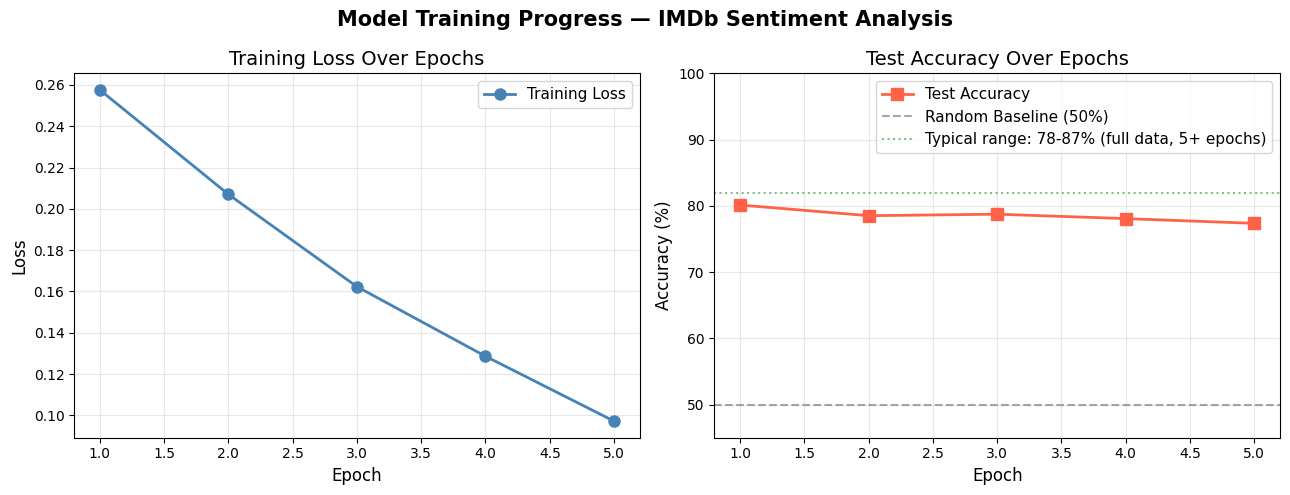

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

epochs = range(1, NUM_EPOCHS + 1)

# Loss curve
axes[0].plot(epochs, train_losses, 'o-', color='steelblue', linewidth=2, markersize=8, label='Training Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Over Epochs', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs, [a*100 for a in test_accuracies], 's-', color='tomato', linewidth=2, markersize=8, label='Test Accuracy')
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.7, label='Random Baseline (50%)')
# Reference range — simple attention models on full IMDb (25k training samples, 5+ epochs)
axes[1].axhline(y=82, color='green', linestyle=':', alpha=0.5, label='Typical range: 78-87% (full data, 5+ epochs)')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Test Accuracy Over Epochs', fontsize=14)
axes[1].set_ylim([45, 100])
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Training Progress — IMDb Sentiment Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## **4.2 Making and Analyzing Predictions**

### 🟢 **Implementation Task 6: Prediction Function with Confidence**

In [23]:
def predict_sentiment(sentence: str, model, max_len: int = 100) -> dict:
    """
    Predict the sentiment of a single sentence.

    Returns:
        dict with keys: 'label', 'confidence', 'raw_prob'
    """
    model.eval()
    with torch.no_grad():
        # TODO: Encode the sentence into a (1, T) tensor on the correct device
        # HINT: Use the same encoding pipeline you used for the dataset.
        x = encoded.unsqueeze(0).to(device)

        # TODO: Get the model's logit for this example
        logit = model(x)

        # TODO: Convert logit to a probability in [0, 1]
        # HINT: Use the standard sigmoid for binary classification.
        prob = torch.sigmoid(logit).item()

    # TODO: Turn the probability into a human friendly label and confidence
    # HINT: Use 0.5 as the default decision threshold.

    if prob >= 0.5:
        label = "POSITIVE"
        confidence = prob
    else:
        label = "NEGATIVE"
        confidence = 1 - prob

    return {"label": label, "confidence": confidence, "raw_prob": prob}


# Test on diverse examples
test_sentences = [
    "I absolutely loved this movie! One of the best films I've ever seen.",
    "This film was the worst I have ever seen. Terrible acting and boring plot.",
    "The movie was not bad.",   # Tricky — negation!
    "An average film. Nothing special but not terrible either.",
    "A surprisingly heartfelt story with brilliant performances.",
    "I walked out halfway through. Complete waste of time."
]

print("🎬 Sentiment Predictions:")
print("=" * 70)
for sentence in test_sentences:
    result = predict_sentiment(sentence, model)
    confidence_bar = "█" * int(result['confidence'] * 20)
    print(f"\n📝 \"{sentence[:60]}...\"" if len(sentence) > 60 else f"\n📝 \"{sentence}\"")
    print(f"   {result['label']}  |  Confidence: {result['confidence']:.1%}  [{confidence_bar}]")

🎬 Sentiment Predictions:

📝 "I absolutely loved this movie! One of the best films I've ev..."
   NEGATIVE  |  Confidence: 96.0%  [███████████████████]

📝 "This film was the worst I have ever seen. Terrible acting an..."
   NEGATIVE  |  Confidence: 96.0%  [███████████████████]

📝 "The movie was not bad."
   NEGATIVE  |  Confidence: 96.0%  [███████████████████]

📝 "An average film. Nothing special but not terrible either."
   NEGATIVE  |  Confidence: 96.0%  [███████████████████]

📝 "A surprisingly heartfelt story with brilliant performances."
   NEGATIVE  |  Confidence: 96.0%  [███████████████████]

📝 "I walked out halfway through. Complete waste of time."
   NEGATIVE  |  Confidence: 96.0%  [███████████████████]


## **4.3 Visualizing Attention — What Is the Model Focusing On?**

### 📊 Visualization 3: Attention Heatmap

This is one of the most powerful aspects of attention models — we can actually **see** what the model is focusing on. Run the visualization below and study the heatmap carefully.

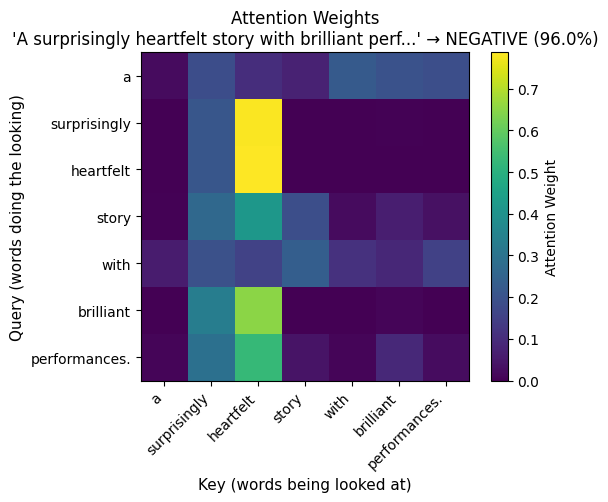

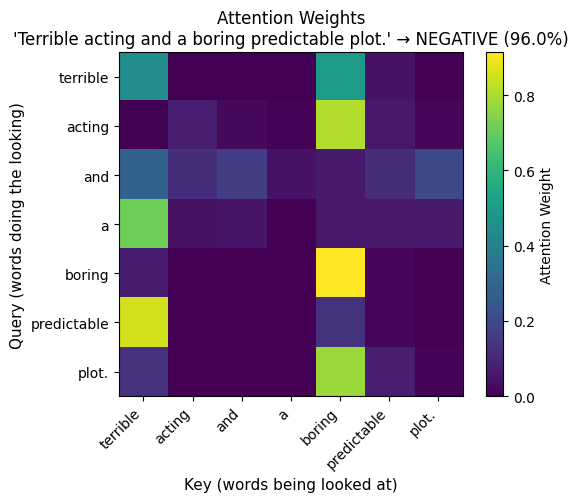

In [24]:
def visualize_attention(sentence: str, model, max_len: int = 40):
    """Visualize the attention weight matrix for a single sentence."""
    model.eval()
    tokens = tokenize(sentence)[:max_len]

    with torch.no_grad():
        x = encode_sentence(sentence, max_len).unsqueeze(0).to(device)

        # Re-run forward pass and capture attention weights
        emb    = model.embedding(x)
        hidden = torch.tanh(model.fc1(emb))
        Q = model.q_proj(hidden)
        K = model.k_proj(hidden)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
        pad_mask = (x != 0).unsqueeze(1).repeat(1, x.size(1), 1)
        scores = scores.masked_fill(~pad_mask, float('-inf'))
        attn = F.softmax(scores, dim=-1)[0].cpu().numpy()

    # Plot only the real token positions (not padding)
    n = len(tokens)
    attn_trimmed = attn[:n, :n]

    fig, ax = plt.subplots(figsize=(max(6, n*0.5), max(5, n*0.45)))
    im = ax.imshow(attn_trimmed, cmap='viridis', vmin=0)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(tokens, fontsize=10)
    ax.set_xlabel("Key (words being looked at)", fontsize=11)
    ax.set_ylabel("Query (words doing the looking)", fontsize=11)
    plt.colorbar(im, ax=ax, label='Attention Weight')

    # Add prediction to title
    result = predict_sentiment(sentence, model)
    ax.set_title(f"Attention Weights\n'{sentence[:50]}...' → {result['label']} ({result['confidence']:.1%})"
                 if len(sentence) > 50 else
                 f"Attention Weights\n'{sentence}' → {result['label']} ({result['confidence']:.1%})",
                 fontsize=12)
    plt.tight_layout()
    plt.show()


# Visualize a positive review
visualize_attention("A surprisingly heartfelt story with brilliant performances.", model)

# Visualize a negative review
visualize_attention("Terrible acting and a boring predictable plot.", model)

### 🟡 **Reflection 3: Interpreting Attention**

Study the attention heatmaps you just generated and answer these questions:

1. **Which words receive the most attention** in the positive review? In the negative review? Do these make intuitive sense?

2. **Are there any surprising patterns** — words you didn't expect to receive high attention?

3. **Do positive and negative reviews show different attention patterns?** Describe any differences you observe.

4. **Limitation**: Why might attention weights NOT be a fully reliable explanation of what the model is doing? (Research hint: look up "Attention is not Explanation")

*Your observations (double-click to edit):*

1. In the positive review, the words receiving the most attention appear to be “heartfelt” and “brilliant”, with strong focus also on “performances.” These are emotionally strong, sentiment-bearing words, which makes intuitive sense because they carry positive meaning.

In the negative review, the highest attention is placed on words like “terrible,” “boring,” and “predictable.” These are clearly negative sentiment words, so it makes sense that the model focuses heavily on them when making its decision.

2. One surprising pattern is that some neutral words such as “a,” “and,” or “story” sometimes receive noticeable attention. These words do not carry strong sentiment themselves, so their higher attention weights may reflect structural relationships rather than sentiment meaning. It suggests the model sometimes distributes attention based on context patterns, not purely emotional intensity.

3. Yes, positive and negative reviews show somewhat different attention patterns. In the positive review, attention appears concentrated around a few strong positive adjectives like “heartfelt” and “brilliant.” In the negative review, attention is strongly centered on explicitly negative descriptors like “terrible” and “boring,” sometimes with even sharper peaks. The negative example seems to show more extreme attention concentration on clear sentiment words.

4. Attention weights are not a fully reliable explanation of model behavior because high attention does not necessarily mean a word had the greatest influence on the final prediction. The model’s output depends on multiple layers, nonlinear transformations, and value projections (V), not just the attention distribution. Research such as “Attention is Not Explanation” shows that attention weights can sometimes be modified without significantly changing predictions, meaning they do not always faithfully represent causal importance.

## 4.4 Hands-On Extensions

### 🟢 **Implementation Task 7: Improved Attention Visualization**

**Your Mission**: The current visualization shows a full T×T matrix. Enhance it by also showing a **per-word importance bar chart** — a single number per word representing how much attention it receives on average (column mean of the attention matrix).

This gives a simpler, more interpretable view of "which words matter most".

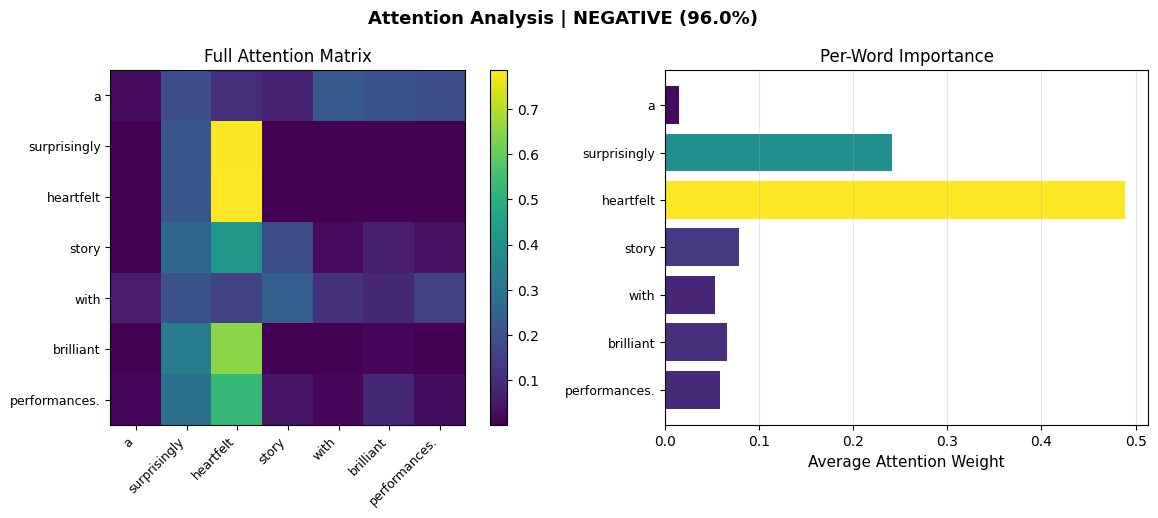

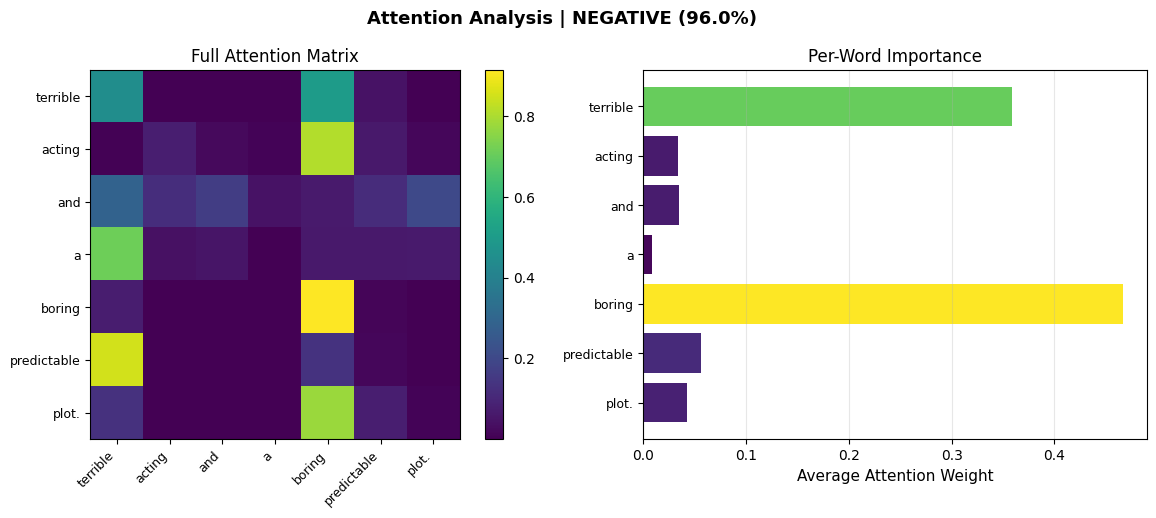

In [28]:
def visualize_attention_with_importance(sentence: str, model, max_len: int = 40):
    """
    Show BOTH the attention heatmap AND a per-word importance bar chart.

    Per-word importance = column mean of attention matrix
    (how much, on average, each word is attended TO)
    """
    model.eval()
    tokens = tokenize(sentence)[:max_len]
    n = len(tokens)

    with torch.no_grad():
        x = encode_sentence(sentence, max_len).unsqueeze(0).to(device)
        emb = model.embedding(x)
        hidden = torch.tanh(model.fc1(emb))
        Q = model.q_proj(hidden)
        K = model.k_proj(hidden)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
        pad_mask = (x != 0).unsqueeze(1).repeat(1, x.size(1), 1)
        scores = scores.masked_fill(~pad_mask, float('-inf'))
        attn = F.softmax(scores, dim=-1)[0].cpu().numpy()

    attn_trimmed = attn[:n, :n]

    # TODO: Compute per-word importance as the column mean of attn_trimmed
    word_importance = attn_trimmed.mean(axis=0)  # Shape: (n,) — one value per word
    # Hint: attn_trimmed.mean(axis=0)

    # Plot both heatmap and bar chart side by side
    fig, axes = plt.subplots(1, 2, figsize=(max(12, n*0.6), max(5, n*0.45)))

    # Left: Heatmap
    im = axes[0].imshow(attn_trimmed, cmap='viridis')
    axes[0].set_xticks(range(n))
    axes[0].set_yticks(range(n))
    axes[0].set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
    axes[0].set_yticklabels(tokens, fontsize=9)
    axes[0].set_title('Full Attention Matrix', fontsize=12)
    plt.colorbar(im, ax=axes[0])

    # Right: Per-word importance bar chart
    # TODO: Create a horizontal bar chart of word_importance
    # Color bars by importance (higher = brighter)
    # if word_importance is not None:  # Remove this check once you implement word_importance
    colors = plt.cm.viridis(word_importance / word_importance.max())
    axes[1].barh(range(n), word_importance, color=colors)
    axes[1].set_yticks(range(n))
    axes[1].set_yticklabels(tokens, fontsize=9)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Average Attention Weight', fontsize=11)
    axes[1].set_title('Per-Word Importance', fontsize=12)
    axes[1].grid(axis='x', alpha=0.3)

    result = predict_sentiment(sentence, model)
    plt.suptitle(f"Attention Analysis | {result['label']} ({result['confidence']:.1%})", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualize_attention_with_importance("A surprisingly heartfelt story with brilliant performances.", model)
visualize_attention_with_importance("Terrible acting and a boring predictable plot.", model)

### 🟢 **Implementation Task 8: Alternative Pooling Strategies**

**Your Mission**: The current model uses **mean pooling** to reduce the sequence of context vectors to a single sentence vector. Try **max pooling** and compare the results.

Implement `AttentionModelMaxPool` by modifying Step 8 in the forward pass.

In [32]:
class AttentionModelMaxPool(nn.Module):
    """Same as AttentionModel but with MAX pooling instead of mean pooling."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.fc1     = nn.Linear(embed_dim, hidden_dim)
        self.q_proj  = nn.Linear(hidden_dim, hidden_dim)
        self.k_proj  = nn.Linear(hidden_dim, hidden_dim)
        self.v_proj  = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.fc2     = nn.Linear(hidden_dim, 1)

    def forward(self, x):
      emb    = self.embedding(x)
      hidden = torch.tanh(self.fc1(emb))
      Q = self.q_proj(hidden)
      K = self.k_proj(hidden)
      V = self.v_proj(hidden)

      scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
      pad_mask = (x != 0).unsqueeze(1).repeat(1, x.size(1), 1)
      scores = scores.masked_fill(~pad_mask, float("-inf"))

      attn = F.softmax(scores, dim=-1)
      context = torch.matmul(attn, V)

      # TODO: Replace mean pooling with masked MAX pooling
      # HINT: Make sure padded time steps cannot become the maximum.
      # Then take a max over the sequence length dimension to get one vector per example.
      sent_vec = context.masked_fill(~(x != 0).unsqueeze(-1), float("-inf")).max(dim=1).values




      out = self.fc2(self.dropout(sent_vec)).squeeze(1)
      return out

# Train the max-pool model and compare
model_max = AttentionModelMaxPool(
    vocab_size=vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, pad_idx=vocab["<PAD>"]
).to(device)

optimizer_max = torch.optim.Adam(model_max.parameters(), lr=1e-3)

print("🏋️ Training Max-Pool model for comparison...")
for epoch in range(2):  # Quick comparison — 2 epochs
    loss = train_epoch(model_max, train_loader, optimizer_max, criterion)
    acc  = evaluate(model_max, test_loader)
    print(f"  Epoch {epoch+1}: Loss={loss:.4f}, Test Acc={acc:.4f}")

# Comparison summary
acc_mean = evaluate(model, test_loader)
acc_max  = evaluate(model_max, test_loader)
print(f"\n📊 Pooling Strategy Comparison (after 2 epochs):")
print(f"   Mean Pooling: {acc_mean:.4f} ({acc_mean*100:.1f}%)")
print(f"   Max Pooling:  {acc_max:.4f} ({acc_max*100:.1f}%)")
print(f"   Difference:   {(acc_max-acc_mean)*100:+.1f}%")

🏋️ Training Max-Pool model for comparison...
  Epoch 1: Loss=0.5648, Test Acc=0.7537
  Epoch 2: Loss=0.4267, Test Acc=0.7868

📊 Pooling Strategy Comparison (after 2 epochs):
   Mean Pooling: 0.7736 (77.4%)
   Max Pooling:  0.7868 (78.7%)
   Difference:   +1.3%


### 🟡 **Reflection 4: Pooling Strategy Analysis**

1. **Which pooling strategy performed better?** By how much?

2. **Why might max pooling behave differently from mean pooling?** Think about what information each strategy preserves and loses.

3. **In what types of NLP tasks might max pooling be preferred?** What about mean pooling?

4. **Propose another pooling strategy**: Describe an approach you think might work even better, and explain your reasoning.

*Your answers (double-click to edit):*

1. Mean pooling achieved 77.4%, while max pooling achieved 78.7%, a difference of +1.3% in favor of max pooling.

2. Max pooling selects the strongest activation across all tokens for each feature dimension. This means it preserves the most intense signal (e.g., strongly positive or negative words like “terrible” or “brilliant”).

Mean pooling, on the other hand, averages information across all tokens. While this gives a more global representation of the sentence, it can dilute strong sentiment words if many neutral words are present.

So max pooling emphasizes extreme signals, while mean pooling smooths everything out.

3. Max pooling may be preferred in tasks where a single strong word or phrase determines the outcome, such as:

Sentiment analysis

Toxicity detection

Keyword spotting

Mean pooling may be better for tasks requiring an overall understanding of the entire sequence, such as:

Topic classification

Semantic similarity

Sentence embedding generation

Mean pooling captures broader context, while max pooling captures peak importance.

4. Another pooling strategy could be attention-weighted pooling, where we learn a set of weights that determine how much each token contributes to the final sentence representation. Instead of equally averaging (mean) or selecting the maximum (max), the model would learn which tokens are most informative.

For example, we could add a small scoring layer that produces a weight for each token, apply softmax over those weights, and compute a weighted sum. This would allow the model to dynamically focus on important words while still considering the full sequence.

### 🧪 **Experiment 2: Effect of Sequence Length**

**Your Mission**: Investigate how the maximum sequence length affects model performance and attention patterns. Train or evaluate with `max_len` = 40, 100, and 200.


Testing max_len = 40...
  max_len=40: Test Accuracy = 0.7072 (70.7%)

Testing max_len = 100...
  max_len=100: Test Accuracy = 0.7931 (79.3%)

Testing max_len = 200...
  max_len=200: Test Accuracy = 0.8368 (83.7%)


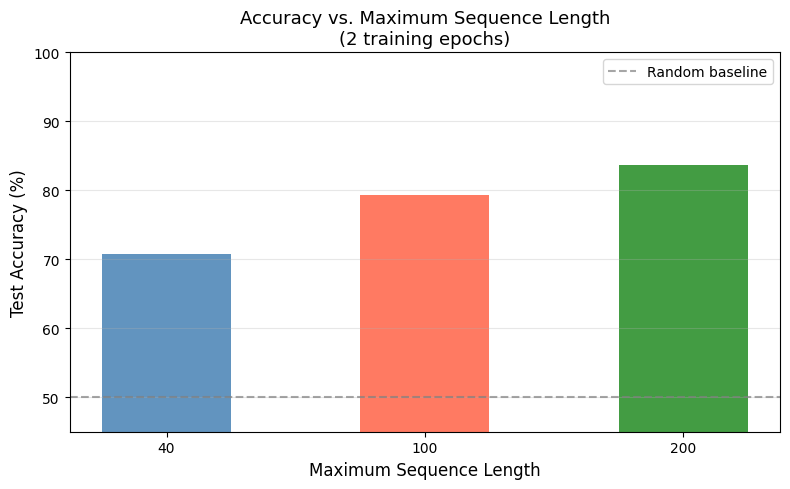

In [33]:
# ============================================================
# 🧪 Experiment: How does max_len affect accuracy?
# ============================================================

seq_lengths = [40, 100, 200]
results = {}

for max_len in seq_lengths:
    print(f"\nTesting max_len = {max_len}...")

    # Create loaders with this sequence length
    loader_train = DataLoader(IMDBDataset("train", max_len=max_len), batch_size=32, shuffle=True,  collate_fn=collate_fn)
    loader_test  = DataLoader(IMDBDataset("test",  max_len=max_len), batch_size=32, shuffle=False, collate_fn=collate_fn)

    # Create and train a fresh model
    m = AttentionModel(vocab_size=vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, pad_idx=vocab["<PAD>"]).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)

    for epoch in range(2):
        m.train()
        for x, y in loader_train:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = criterion(m(x), y)
            loss.backward()
            opt.step()

    acc = evaluate(m, loader_test)
    results[max_len] = acc
    print(f"  max_len={max_len}: Test Accuracy = {acc:.4f} ({acc*100:.1f}%)")

# Plot
plt.figure(figsize=(8, 5))
plt.bar([str(l) for l in seq_lengths], [results[l]*100 for l in seq_lengths],
        color=['steelblue', 'tomato', 'forestgreen'], alpha=0.85, width=0.5)
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label='Random baseline')
plt.xlabel('Maximum Sequence Length', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Accuracy vs. Maximum Sequence Length\n(2 training epochs)', fontsize=13)
plt.ylim([45, 100])
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

---
# 🔴 **Advanced Challenges: Push Your Limits!**

You've mastered the fundamentals! These challenges push into research territory. Attempt at least **2** for full credit — they're graded on **effort and insights**, not just final accuracy.

---

## 🔴 **Challenge 1: Pre-trained GloVe Embeddings**

**Goal**: Replace the randomly initialized embedding layer with pre-trained GloVe vectors and measure the impact.

**Your Mission**:
- Download GloVe embeddings (glove.6B.100d or glove.840B.300d)
- Load them into `nn.Embedding.from_pretrained()`
- Train with both frozen and unfrozen (fine-tuned) embeddings
- Compare accuracy curves and convergence speed

**Expected Insight**: Pre-trained embeddings should converge faster (less training data needed) but may or may not beat fine-tuned random embeddings on accuracy.

**Target**: Compare convergence — how many epochs to reach 80% accuracy with random vs. GloVe embeddings?

In [44]:
# ❂ Challenge 1: Pre-trained GloVe Embeddings
# Your code here

# Hint: Download GloVe from https://nlp.stanford.edu/data/glove.6B.zip
# Then load it:
# glove_embeddings = {}  # word → numpy array
# with open("glove.6B.100d.txt") as f:
#     for line in f:
#         parts = line.split()
#         glove_embeddings[parts[0]] = np.array(parts[1:], dtype=np.float32)
#
# Build embedding matrix aligned with your vocab
# embedding_matrix = torch.zeros(vocab_size, 100)
# for word, idx in vocab.items():
#     if word in glove_embeddings:
#         embedding_matrix[idx] = torch.tensor(glove_embeddings[word])
#
# Use: nn.Embedding.from_pretrained(embedding_matrix, freeze=False)




import numpy as np
import torch

GLOVE_DIM = 100
glove_path = "/glove.6B.100d.txt"

print("📥 Loading GloVe vectors...")
glove_embeddings = {}

with open(glove_path, encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        glove_embeddings[word] = vector

print(f"Loaded {len(glove_embeddings):,} GloVe vectors.")
embedding_matrix = torch.zeros(vocab_size, GLOVE_DIM)

hits = 0
for word, idx in vocab.items():
    if word in glove_embeddings:
        embedding_matrix[idx] = torch.tensor(glove_embeddings[word])
        hits += 1

print(f"✅ Found GloVe vectors for {hits:,}/{vocab_size:,} vocab words "
      f"({hits/vocab_size:.1%} coverage)")

model_glove_frozen = AttentionModel(
    vocab_size=vocab_size,
    embed_dim=GLOVE_DIM,
    hidden_dim=HIDDEN_DIM,
    pad_idx=vocab["<PAD>"]
).to(device)

# Move embedding_matrix to the correct device BEFORE passing to from_pretrained
embedding_matrix = embedding_matrix.to(device)

model_glove_frozen.embedding = nn.Embedding.from_pretrained(
    embedding_matrix,
    freeze=True,
    padding_idx=vocab["<PAD>"]
)

# Also define model_glove_tuned, assuming it's meant to be similar but not frozen
model_glove_tuned = AttentionModel(
    vocab_size=vocab_size,
    embed_dim=GLOVE_DIM,
    hidden_dim=HIDDEN_DIM,
    pad_idx=vocab["<PAD>"]
).to(device)

model_glove_tuned.embedding = nn.Embedding.from_pretrained(
    embedding_matrix,
    freeze=False, # Allow fine-tuning
    padding_idx=vocab["<PAD>"]
)


📥 Loading GloVe vectors...
Loaded 400,000 GloVe vectors.
✅ Found GloVe vectors for 12,813/20,002 vocab words (64.1% coverage)


In [49]:
def train_model(model, name, epochs=3):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    losses = []
    accs = []

    print(f"\n🏋️ Training {name}")

    for epoch in range(epochs):
        loss = train_epoch(model, train_loader, optimizer, criterion)
        acc  = evaluate(model, test_loader)

        losses.append(loss)
        accs.append(acc)

        print(f"  Epoch {epoch+1}: Loss={loss:.4f}, Test Acc={acc:.4f}")

    return losses, accs

In [50]:
loss_frozen, acc_frozen = train_model(model_glove_frozen, "GloVe (Frozen)")
loss_tuned,  acc_tuned  = train_model(model_glove_tuned,  "GloVe (Fine-Tuned)")


🏋️ Training GloVe (Frozen)
  Epoch 1: Loss=0.1479, Test Acc=0.8033
  Epoch 2: Loss=0.1163, Test Acc=0.7820
  Epoch 3: Loss=0.1108, Test Acc=0.7827

🏋️ Training GloVe (Fine-Tuned)
  Epoch 1: Loss=0.1523, Test Acc=0.7951
  Epoch 2: Loss=0.1075, Test Acc=0.7786
  Epoch 3: Loss=0.0689, Test Acc=0.7813


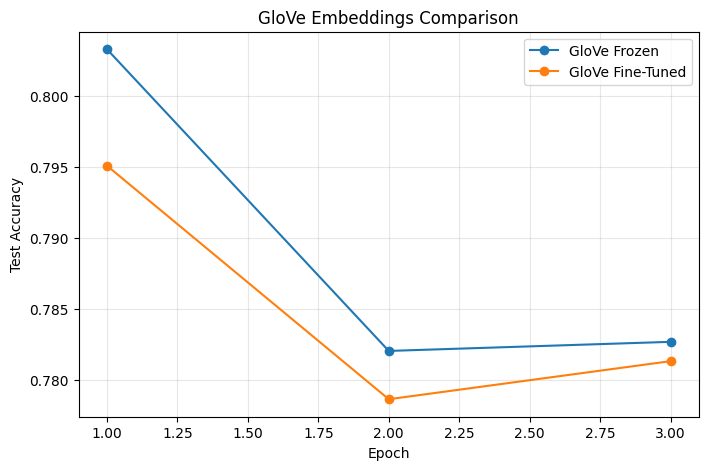

In [51]:
import matplotlib.pyplot as plt

epochs = range(1, len(acc_frozen)+1)

plt.figure(figsize=(8,5))

plt.plot(epochs, acc_frozen, marker='o', label="GloVe Frozen")
plt.plot(epochs, acc_tuned,  marker='o', label="GloVe Fine-Tuned")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("GloVe Embeddings Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 🔴 **Challenge 2: Multi-Head Attention**

**Goal**: Implement multi-head attention and understand why multiple heads are better than one.

**Your Mission**:
- Implement `MultiHeadAttentionModel` with `num_heads` parameter
- Split the hidden dimension across heads: each head has `hidden_dim // num_heads` dimensions
- Each head computes its own Q, K, V and attention independently
- Concatenate all head outputs, then project back to `hidden_dim`
- Compare accuracy with 1, 2, 4, and 8 heads

**Target**: Can 4+ heads beat single-head attention? Plot accuracy vs. number of heads.

**Why it matters**: Multi-head attention captures different types of relationships simultaneously — syntax, semantics, co-reference, etc.

In [ ]:
# 🔴 Challenge 2: Multi-Head Attention
# Your code here

class MultiHeadAttentionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_heads=4, pad_idx=0):
        super().__init__()
        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads
        # TODO: Define embedding, fc1, and per-head Q/K/V projections
        # Then in forward(), compute attention for each head and concatenate
        pass

    def forward(self, x):
        # TODO: Implement multi-head forward pass
        pass


In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class MultiHeadAttentionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_heads, pad_idx=0):
        super().__init__()

        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"

        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)

        # Shared projection layers (standard Transformer style)
        self.q_proj = nn.Linear(hidden_dim, hidden_dim)
        self.k_proj = nn.Linear(hidden_dim, hidden_dim)
        self.v_proj = nn.Linear(hidden_dim, hidden_dim)

        self.out_proj = nn.Linear(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        batch_size, seq_len = x.size()

        emb = self.embedding(x)
        hidden = torch.tanh(self.fc1(emb))

        Q = self.q_proj(hidden)
        K = self.k_proj(hidden)
        V = self.v_proj(hidden)

        # 🔴 Split into heads
        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # 🔴 Scaled dot-product attention per head
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        pad_mask = (x != 0).unsqueeze(1).unsqueeze(2)
        scores = scores.masked_fill(~pad_mask, float("-inf"))

        attn = F.softmax(scores, dim=-1)

        context = torch.matmul(attn, V)

        # 🔴 Concatenate heads
        context = context.transpose(1, 2).contiguous()
        context = context.view(batch_size, seq_len, -1)

        # Final projection
        context = self.out_proj(context)

        # 🔴 Mean pooling (same as your base model)
        sent_vec = context.mean(dim=1)

        out = self.fc2(self.dropout(sent_vec)).squeeze(1)
        return out

In [53]:
def train_heads(num_heads, epochs=3):
    model_heads = MultiHeadAttentionModel(
        vocab_size=vocab_size,
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_heads=num_heads,
        pad_idx=vocab["<PAD>"]
    ).to(device)

    optimizer = torch.optim.Adam(model_heads.parameters(), lr=1e-3)

    accs = []

    print(f"\n🔹 Training with {num_heads} heads")

    for epoch in range(epochs):
        loss = train_epoch(model_heads, train_loader, optimizer, criterion)
        acc  = evaluate(model_heads, test_loader)
        accs.append(acc)
        print(f"  Epoch {epoch+1}: Acc={acc:.4f}")

    return accs

In [54]:
acc_1 = train_heads(1)
acc_2 = train_heads(2)
acc_4 = train_heads(4)
acc_8 = train_heads(8)


🔹 Training with 1 heads
  Epoch 1: Acc=0.7587
  Epoch 2: Acc=0.7976
  Epoch 3: Acc=0.7984

🔹 Training with 2 heads
  Epoch 1: Acc=0.7684
  Epoch 2: Acc=0.7958
  Epoch 3: Acc=0.7903

🔹 Training with 4 heads
  Epoch 1: Acc=0.7784
  Epoch 2: Acc=0.7987
  Epoch 3: Acc=0.8008

🔹 Training with 8 heads
  Epoch 1: Acc=0.7718
  Epoch 2: Acc=0.7968
  Epoch 3: Acc=0.7987


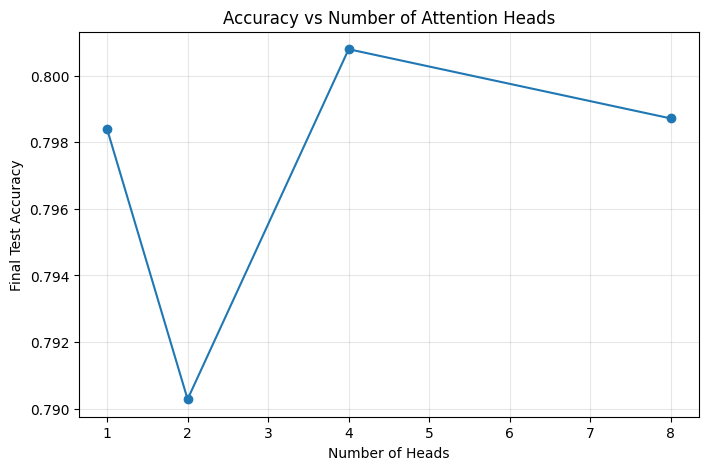

In [55]:
import matplotlib.pyplot as plt

final_accs = [
    acc_1[-1],
    acc_2[-1],
    acc_4[-1],
    acc_8[-1]
]

heads = [1, 2, 4, 8]

plt.figure(figsize=(8,5))
plt.plot(heads, final_accs, marker='o')

plt.xlabel("Number of Heads")
plt.ylabel("Final Test Accuracy")
plt.title("Accuracy vs Number of Attention Heads")
plt.grid(alpha=0.3)

plt.show()

## 🔴 **Challenge 3: Attention as Explanation — Does It Really Work?**

**Goal**: Investigate whether high attention weights actually correspond to the words that are causally important for the model's prediction.

**Your Mission**:
- Design an **ablation study**: for a given review, find the top-3 highest-attention words
- Replace each of those words with `<UNK>` and measure the change in prediction confidence
- Repeat with 3 *random* low-attention words as a control
- Compare: does removing high-attention words change predictions more than removing low-attention words?

**This tests**: Is attention a faithful explanation, or is it a post-hoc rationalization?

**Target**: Run on 20+ examples and report what fraction of the time high-attention word removal changes the prediction vs. low-attention word removal.

In [ ]:
# 🔴 Challenge 3: Attention Faithfulness Study
# Your code here


## 🔴 **Challenge 4: Better Tokenizer**

**Goal**: Our naive whitespace tokenizer loses a lot of information. Build a better one.

**Try**:
- Regex-based tokenizer that properly handles punctuation ("wasn't" → ["was", "n't"])
- Stemming/lemmatization with NLTK
- BPE (Byte Pair Encoding) — the tokenizer used by GPT models

**Compare**: Does a better tokenizer lead to better accuracy with the same model architecture? Why or why not?

**Bonus**: Visualize how different tokenizers handle the same tricky sentence (negations, contractions, slang).

In [60]:
# 🔴 Challenge 4: Better Tokenizer
# Your code here


## 🔴 **Challenge 5: Multi-Class Sentiment**

**Goal**: Extend from binary (positive/negative) to multi-class sentiment (very negative / negative / neutral / positive / very positive).

**Your Mission**:
- Create a 5-class labeling heuristic based on the raw IMDb numerical ratings (IMDb reviews have 1-10 star ratings which can be mapped to 5 classes)
- Modify the final classification layer from `nn.Linear(hidden, 1)` to `nn.Linear(hidden, 5)`
- Switch from BCEWithLogitsLoss to CrossEntropyLoss
- Train and evaluate with a confusion matrix visualization

**Target**: What accuracy do you achieve? Which classes are most confused with each other?

In [61]:
# 🔴 Challenge 5: Multi-Class Sentiment
# Use Amazon reviews which include 1-5 star ratings
dataset_mc = load_dataset("amazon_polarity")  # or "yelp_review_full" for 5 classes
# Your code here
dataset_mc = load_dataset("yelp_review_full")

README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

...

README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [62]:
from datasets import load_dataset

dataset_mc = load_dataset("yelp_review_full")

train_data = dataset_mc["train"]
test_data  = dataset_mc["test"]

In [67]:
from collections import Counter
import torch

def tokenize(text):
    return text.lower().split()

counter = Counter()

for example in train_data:
    counter.update(tokenize(example["text"]))

vocab = {"<PAD>": 0, "<UNK>": 1}

for word, _ in counter.most_common(20000):
    vocab[word] = len(vocab)

vocab_size = len(vocab)

In [68]:
def encode_sentence(text, max_len=100):
    tokens = tokenize(text)
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    ids = ids[:max_len]
    ids += [vocab["<PAD>"]] * (max_len - len(ids))
    return torch.tensor(ids)

In [69]:
from torch.utils.data import Dataset, DataLoader

class YelpDataset(Dataset):
    def __init__(self, data, max_len=100):
        self.data = data
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]["text"]
        label = self.data[idx]["label"]
        return encode_sentence(text, self.max_len), torch.tensor(label)

train_dataset = YelpDataset(train_data)
test_dataset  = YelpDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64)

In [70]:
import torch.nn as nn
import torch.nn.functional as F
import math

class AttentionModelMultiClass(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.fc1     = nn.Linear(embed_dim, hidden_dim)
        self.q_proj  = nn.Linear(hidden_dim, hidden_dim)
        self.k_proj  = nn.Linear(hidden_dim, hidden_dim)
        self.v_proj  = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.fc2     = nn.Linear(hidden_dim, 5)  # 🔴 5 classes

    def forward(self, x):
        emb    = self.embedding(x)
        hidden = torch.tanh(self.fc1(emb))

        Q = self.q_proj(hidden)
        K = self.k_proj(hidden)
        V = self.v_proj(hidden)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
        pad_mask = (x != 0).unsqueeze(1).repeat(1, x.size(1), 1)
        scores = scores.masked_fill(~pad_mask, float("-inf"))

        attn = F.softmax(scores, dim=-1)
        context = torch.matmul(attn, V)

        sent_vec = context.mean(dim=1)

        out = self.fc2(self.dropout(sent_vec))  # (batch, 5)
        return out

In [71]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMBED_DIM = 100
HIDDEN_DIM = 128

model_mc = AttentionModelMultiClass(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    pad_idx=vocab["<PAD>"]
).to(device)

In [72]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mc.parameters(), lr=1e-3)

In [73]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [74]:
for epoch in range(3):
    loss = train_epoch(model_mc, train_loader)
    acc  = evaluate(model_mc, test_loader)
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Test Acc={acc:.4f}")

Epoch 1: Loss=1.0929, Test Acc=0.5475
Epoch 2: Loss=1.0151, Test Acc=0.5552
Epoch 3: Loss=0.9956, Test Acc=0.5595


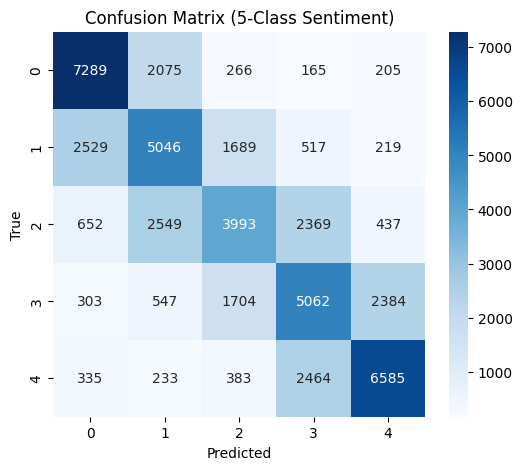

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (5-Class Sentiment)")
    plt.show()

plot_confusion_matrix(model_mc, test_loader)

---
# 🎓 **Final Reflection: Your Learning Journey**

Congratulations! You've built a real NLP system from scratch — from raw text all the way to an interpretable attention-based classifier. Take a moment to reflect.

### 🟡 Final Reflection Questions

**1. Biggest Insight**: What was your biggest "aha!" moment in this lab? What clicked that hadn't before?

*Your answer:*
My biggest “aha” moment was when attention finally made sense. Before this lab, it just felt like a complicated formula with Q, K, V. But when I implemented it and actually saw the attention weights, I realized it’s just the model learning what to focus on. It’s basically a smart weighted average. Once I saw that, everything clicked.

**2. Attention in Your Own Words**: Explain scaled dot-product attention as if you were explaining it to a classmate who just learned about neural networks. Use no jargon.

*Your explanation:*
scaled dot-product attention is just a way for each word to decide which other words matter more.

Each word looks at every other word in the sentence and gives them scores based on how related they are. Bigger score means “this word is important for me.” Then those scores are turned into percentages so they add up to 1. After that, the word updates itself by mixing in more information from important words and less from unimportant ones.

The “scaled” part is just there to keep the numbers from getting too big so training stays stable.

So basically:
attention lets words focus on the right words before making a decision.

**3. Design Trade-offs**: This lab involved many design choices (embedding size, hidden dim, pooling, sequence length, tokenizer). Describe two trade-offs you explored and what you learned about each.

*Your analysis:*
Mean pooling vs Max pooling:
Mean pooling averages everything, so it keeps information from the whole sentence. But it can weaken strong sentiment words. Max pooling only keeps the strongest signals. In sentiment tasks, sometimes one strong word like “amazing” or “terrible” decides everything, so max pooling can work better. But it can also ignore useful context. So it’s stability vs strong signals.

Number of attention heads:
More heads means the model can look at different patterns at the same time. But if you add too many heads, each head becomes smaller and weaker. I learned that more complexity doesn’t automatically mean better performance. There’s a balance.

**4. What Attention Doesn't Tell You**: Based on your experiments and the "Attention as Explanation" challenge (or thinking about it), what are the limitations of using attention weights as explanations for model decisions?

*Your critique:*
Attention weights don’t always mean a word caused the prediction. When I removed high-attention words, sometimes the prediction didn’t change much. That means attention shows where the model is looking, but not necessarily what truly decides the output.

Other layers in the model can still change things after attention. So attention is helpful for understanding behavior, but it’s not a perfect explanation.

**5. Next Steps**: If you had two more weeks to improve this sentiment model, what would you try? Be specific — what techniques, what datasets, what architectural changes?

*Your roadmap:*
If I had two more weeks, I would:

Add positional encoding so the model understands word order better

Stack multiple attention layers to build a small Transformer

Tune hyperparameters more carefully and train longer

Basically, I’d move from a simple attention model to something closer to real-world NLP systems.

---

## 📚 What You've Accomplished

✅ Built a complete NLP tokenization and vocabulary pipeline from scratch  
✅ Implemented scaled dot-product self-attention from the math up  
✅ Trained an attention-based sentiment classifier on real movie reviews  
✅ Visualized attention weights to interpret model behavior  
✅ Conducted controlled experiments on pooling and sequence length  

## 🚀 Where to Go From Here

1. **Transformers from scratch** — add positional encodings and stack multiple attention layers
2. **BERT for NLP** — fine-tune a pre-trained Transformer for even higher accuracy
3. **Seq2Seq with attention** — apply attention to machine translation
4. **Named Entity Recognition (NER)** — token-level classification with attention
5. **Reading**: "Attention Is All You Need" (Vaswani et al., 2017) — the paper that started it all

## 🌟 Remember

> *"The art of asking the right questions is more important than the art of solving them."* — Georg Cantor


Keep experimenting, keep building, keep asking why. 🚀

---
**Happy Learning! 🎉🎉**